# Comparision of different PRNGs (Model 2)

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate the histograms for model 2 shown in the report.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
df_MM1rho90 = pd.read_csv("statistics/results2MM1rho90.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MG1rho90 = pd.read_csv("statistics/results2MG1rho90.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MM1rho95 = pd.read_csv("statistics/results2MM1rho95.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")
df_MG1rho95 = pd.read_csv("statistics/results2MG1rho95.txt", header=None, names=["rng_mode", "EW", "EV", "ENQ", "EN", "time"], sep="\t")

In [3]:
generators=df_MM1rho90["rng_mode"].drop_duplicates().tolist()

### Colors for generator types

In [4]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

def color_labels(ax):
    for label in ax.get_xticklabels():
        label.set_color(color_from_name(label.get_text()))

def color_boxes(ax):
    for i, generator in enumerate(generators):
        c = color_from_name(generator)
        if c == 'black':
            continue
        ax.axvspan(0.5+i, 1.5+i, facecolor=c, alpha=0.1, edgecolor='none', zorder=-10)

def color_all(fig):
    axes = fig.axes
    for ax in axes:
        color_boxes(ax)
    color_labels(axes[-1])

## Generate boxplots for $\mathbf{E}[W]$ for the different models

In [5]:
EW1 = [(df_MM1rho90[df_MM1rho90["rng_mode"] == generator]["EW"] - 810) / 810 * 100 for generator in generators]
EW2 = [(df_MM1rho95[df_MM1rho95["rng_mode"] == generator]["EW"] - 1805) / 1805 * 100 for generator in generators]
EW3 = [(df_MG1rho90[df_MG1rho90["rng_mode"] == generator]["EW"] - 506.25) / 506.25 * 100 for generator in generators]
EW4 = [(df_MG1rho95[df_MG1rho95["rng_mode"] == generator]["EW"] - 1105) / 1105 * 100 for generator in generators]

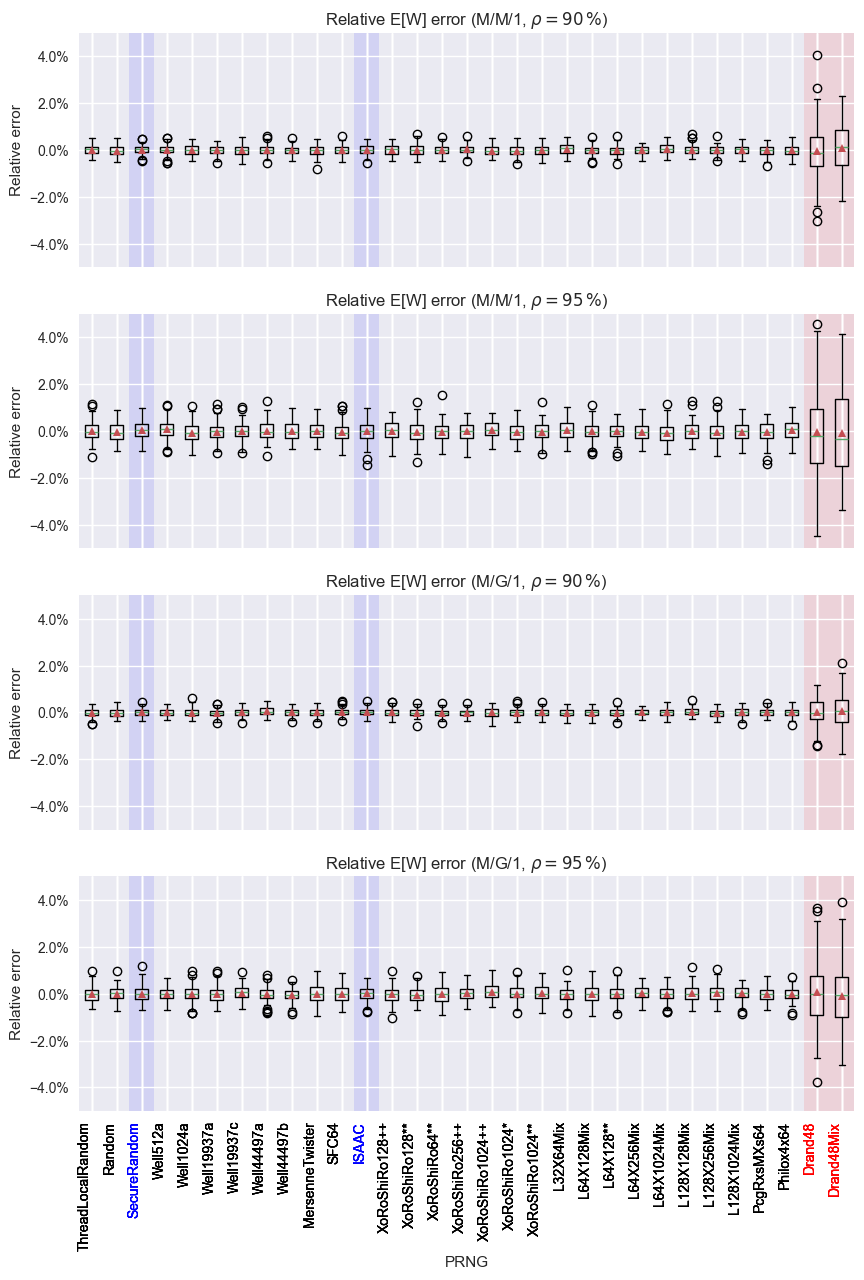

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 14), sharey='row', sharex='col')

ax1.boxplot(EW1, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax2.boxplot(EW2, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax3.boxplot(EW3, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore
ax4.boxplot(EW4, tick_labels=range(1, len(generators) + 1), showmeans=True)  # type: ignore

ax1.set_title("Relative E[W] error (M/M/1, $\\rho=90\\,\\%$)")
ax1.set_ylabel("Relative error")

ax2.set_title("Relative E[W] error (M/M/1, $\\rho=95\\,\\%$)")
ax2.set_ylabel("Relative error")

ax3.set_title("Relative E[W] error (M/G/1, $\\rho=90\\,\\%$)")
ax3.set_ylabel("Relative error")

ax4.set_title("Relative E[W] error (M/G/1, $\\rho=95\\,\\%$)")
ax4.set_xlabel("PRNG")
ax4.set_ylabel("Relative error")
ax4.set_xticklabels(generators + generators + generators + generators, rotation=90, ha='right')

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

ax1.set_ylim([-5, 5])
ax2.set_ylim([-5, 5])
ax3.set_ylim([-5, 5])
ax4.set_ylim([-5, 5])

color_all(fig)

# fig.savefig("PRNG-DES-Benchmarks-Figures-plot2.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

# fig.savefig("plot2.png", format="png", bbox_inches='tight', pad_inches=0)

## Interquartile range

In [7]:
iqr_MM1_90=[]
iqr_MM1_95=[]
iqr_MG1_90=[]
iqr_MG1_95=[]

for i, generator in enumerate(generators):
    q1, q3 = np.quantile(EW1[i], [0.25, 0.75])
    iqr_MM1_90.append(q3 - q1)
    q1, q3 = np.quantile(EW2[i], [0.25, 0.75])
    iqr_MM1_95.append(q3 - q1)
    q1, q3 = np.quantile(EW3[i], [0.25, 0.75])
    iqr_MG1_90.append(q3 - q1)
    q1, q3 = np.quantile(EW4[i], [0.25, 0.75])
    iqr_MG1_95.append(q3 - q1)

df_iqr=pd.DataFrame({
    "M/M/1, rho=90%": iqr_MM1_90,
    "M/M/1, rho=95%": iqr_MM1_95,
    "M/G/1, rho=90%": iqr_MG1_90,
    "M/G/1, rho=95%": iqr_MG1_95
}, index=generators)


All values are percent points.

In [8]:
df_iqr

,"M/M/1, rho=90%","M/M/1, rho=95%","M/G/1, rho=90%","M/G/1, rho=95%"
ThreadLocalRandom,0.284721,0.491784,0.227531,0.453057
Random,0.282075,0.596726,0.247691,0.394687
SecureRandom,0.217465,0.514760,0.198358,0.438210
Well512a,0.233529,0.460753,0.224316,0.360364
Well1024a,0.325594,0.575425,0.233956,0.403833
Well19937a,0.256746,0.449905,0.196139,0.415739
Well19937c,0.299503,0.457881,0.214358,0.405614
Well44497a,0.249590,0.537085,0.263485,0.328752
Well44497b,0.236584,0.555465,0.210838,0.293939
MersenneTwister,0.278780,0.502042,0.213749,0.553561


### Maximum over first 28 generators

In [9]:
print(np.max(iqr_MM1_90[:23]))
print(np.max(iqr_MM1_95[:23]))
print(np.max(iqr_MG1_90[:23]))
print(np.max(iqr_MG1_95[:23]))

0.34167027058911986
0.5967255949769469
0.28283685576482437
0.5599685040991265


## Generate table for mean errors (not used in the report)

In [10]:
d = {}

df = df_MM1rho90
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 810) / 810 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 900) / 900 * 100, 5))
d["E[W] - MM1"] = EW_error
d["E[V] - MM1"] = EV_error

df = df_MG1rho90
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 506.25) / 506.25 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 596.25) / 596.25 * 100, 5))
d["E[W] - MG1"] = EW_error
d["E[V] - MG1"] = EV_error

df_mean = pd.DataFrame(d, index=generators)

df_mean

,E[W] - MM1,E[V] - MM1,E[W] - MG1,E[V] - MG1
ThreadLocalRandom,0.01406,0.01264,0.00785,0.00665
Random,0.02091,0.01887,0.02623,0.02232
SecureRandom,0.01210,0.01098,0.01822,0.01553
Well512a,0.00558,0.00512,0.00154,0.00145
Well1024a,0.00191,0.00174,0.00916,0.00778
Well19937a,0.00598,0.00542,0.02446,0.02083
Well19937c,0.00333,0.00324,0.01178,0.01004
Well44497a,0.00545,0.00494,0.04793,0.04076
Well44497b,0.00916,0.00830,0.01003,0.00867
MersenneTwister,0.01900,0.01705,0.00176,0.00141


In [11]:

s = df_mean.style.format("{:.3f}\\,\\%").set_caption("Mean Error (in \\%)").set_table_styles([{
    "selector": "caption",
    "props": []
}])
print(s.to_latex())

\begin{table}
\caption{Mean Error (in \%)}
\begin{tabular}{lrrrr}
 & E[W] - MM1 & E[V] - MM1 & E[W] - MG1 & E[V] - MG1 \\
ThreadLocalRandom & 0.014\,\% & 0.013\,\% & 0.008\,\% & 0.007\,\% \\
Random & 0.021\,\% & 0.019\,\% & 0.026\,\% & 0.022\,\% \\
SecureRandom & 0.012\,\% & 0.011\,\% & 0.018\,\% & 0.016\,\% \\
Well512a & 0.006\,\% & 0.005\,\% & 0.002\,\% & 0.001\,\% \\
Well1024a & 0.002\,\% & 0.002\,\% & 0.009\,\% & 0.008\,\% \\
Well19937a & 0.006\,\% & 0.005\,\% & 0.024\,\% & 0.021\,\% \\
Well19937c & 0.003\,\% & 0.003\,\% & 0.012\,\% & 0.010\,\% \\
Well44497a & 0.005\,\% & 0.005\,\% & 0.048\,\% & 0.041\,\% \\
Well44497b & 0.009\,\% & 0.008\,\% & 0.010\,\% & 0.009\,\% \\
MersenneTwister & 0.019\,\% & 0.017\,\% & 0.002\,\% & 0.001\,\% \\
SFC64 & 0.007\,\% & 0.006\,\% & 0.035\,\% & 0.030\,\% \\
ISAAC & 0.022\,\% & 0.020\,\% & 0.030\,\% & 0.026\,\% \\
XoRoShiRo128++ & 0.004\,\% & 0.004\,\% & 0.008\,\% & 0.007\,\% \\
XoRoShiRo128** & 0.009\,\% & 0.008\,\% & 0.007\,\% & 0.006\,\% \\
XoRoS

In [12]:
s = df_mean.style.format("{:.3f}%").set_caption("Mean Error (in \\%)")
print(s.to_html())

<style type="text/css">
</style>
<table id="T_f6d50">
  <caption>Mean Error (in \%)</caption>
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_f6d50_level0_col0" class="col_heading level0 col0" >E[W] - MM1</th>
      <th id="T_f6d50_level0_col1" class="col_heading level0 col1" >E[V] - MM1</th>
      <th id="T_f6d50_level0_col2" class="col_heading level0 col2" >E[W] - MG1</th>
      <th id="T_f6d50_level0_col3" class="col_heading level0 col3" >E[V] - MG1</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_f6d50_level0_row0" class="row_heading level0 row0" >ThreadLocalRandom</th>
      <td id="T_f6d50_row0_col0" class="data row0 col0" >0.014%</td>
      <td id="T_f6d50_row0_col1" class="data row0 col1" >0.013%</td>
      <td id="T_f6d50_row0_col2" class="data row0 col2" >0.008%</td>
      <td id="T_f6d50_row0_col3" class="data row0 col3" >0.007%</td>
    </tr>
    <tr>
      <th id="T_f6d50_level0_row1" class="row_heading level0 row1" >Random</th>
 

In [13]:
d = {}

df = df_MM1rho95
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 810) / 810 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 900) / 900 * 100, 5))
d["E[W] - MM1"] = EW_error
d["E[V] - MM1"] = EV_error

df = df_MG1rho95
EW_error = []
EV_error = []
for generator in generators:
    EW_error.append(round(abs(df[df["rng_mode"] == generator]["EW"].mean() - 506.25) / 506.25 * 100, 5))
    EV_error.append(round(abs(df[df["rng_mode"] == generator]["EV"].mean() - 596.25) / 596.25 * 100, 5))
d["E[W] - MG1"] = EW_error
d["E[V] - MG1"] = EV_error

df_mean = pd.DataFrame(d, index=generators)

df_mean

,E[W] - MM1,E[V] - MM1,E[W] - MG1,E[V] - MG1
ThreadLocalRandom,122.82283,111.09604,118.20937,101.20497
Random,122.72917,111.01162,118.24659,101.23654
SecureRandom,122.96241,111.22177,118.26456,101.25180
Well512a,123.06004,111.30963,118.25211,101.24120
Well1024a,122.71824,111.00194,118.25359,101.24249
Well19937a,122.80741,111.08227,118.21784,101.21222
Well19937c,122.89749,111.16355,118.33847,101.31466
Well44497a,122.86457,111.13376,118.22057,101.21444
Well44497b,122.89121,111.15777,118.16683,101.16889
MersenneTwister,122.85988,111.12931,118.24632,101.23653


In [14]:

s = df_mean.style.format("{:.3f}\\,\\%").set_caption("Mean Error (in \\%)").set_table_styles([{
    "selector": "caption",
    "props": []
}])
print(s.to_latex())

\begin{table}
\caption{Mean Error (in \%)}
\begin{tabular}{lrrrr}
 & E[W] - MM1 & E[V] - MM1 & E[W] - MG1 & E[V] - MG1 \\
ThreadLocalRandom & 122.823\,\% & 111.096\,\% & 118.209\,\% & 101.205\,\% \\
Random & 122.729\,\% & 111.012\,\% & 118.247\,\% & 101.237\,\% \\
SecureRandom & 122.962\,\% & 111.222\,\% & 118.265\,\% & 101.252\,\% \\
Well512a & 123.060\,\% & 111.310\,\% & 118.252\,\% & 101.241\,\% \\
Well1024a & 122.718\,\% & 111.002\,\% & 118.254\,\% & 101.242\,\% \\
Well19937a & 122.807\,\% & 111.082\,\% & 118.218\,\% & 101.212\,\% \\
Well19937c & 122.897\,\% & 111.164\,\% & 118.338\,\% & 101.315\,\% \\
Well44497a & 122.865\,\% & 111.134\,\% & 118.221\,\% & 101.214\,\% \\
Well44497b & 122.891\,\% & 111.158\,\% & 118.167\,\% & 101.169\,\% \\
MersenneTwister & 122.860\,\% & 111.129\,\% & 118.246\,\% & 101.237\,\% \\
SFC64 & 122.748\,\% & 111.029\,\% & 118.248\,\% & 101.237\,\% \\
ISAAC & 122.859\,\% & 111.128\,\% & 118.293\,\% & 101.276\,\% \\
XoRoShiRo128++ & 122.870\,\% & 111.138\,\

In [15]:
s = df_mean.style.format("{:.3f}%").set_caption("Mean Error (in \\%)")
print(s.to_html())

<style type="text/css">
</style>
<table id="T_7facd">
  <caption>Mean Error (in \%)</caption>
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_7facd_level0_col0" class="col_heading level0 col0" >E[W] - MM1</th>
      <th id="T_7facd_level0_col1" class="col_heading level0 col1" >E[V] - MM1</th>
      <th id="T_7facd_level0_col2" class="col_heading level0 col2" >E[W] - MG1</th>
      <th id="T_7facd_level0_col3" class="col_heading level0 col3" >E[V] - MG1</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_7facd_level0_row0" class="row_heading level0 row0" >ThreadLocalRandom</th>
      <td id="T_7facd_row0_col0" class="data row0 col0" >122.823%</td>
      <td id="T_7facd_row0_col1" class="data row0 col1" >111.096%</td>
      <td id="T_7facd_row0_col2" class="data row0 col2" >118.209%</td>
      <td id="T_7facd_row0_col3" class="data row0 col3" >101.205%</td>
    </tr>
    <tr>
      <th id="T_7facd_level0_row1" class="row_heading level0 row1" >Rando